# Advanced: Comparison with HALO-(AC)³ aircraft measurements (thermal)

Here, we simulate the irradiance at 15 output altitudes along the flight path of the HALO, P5 and P6 aircraft during the HALO-(AC)³ campaign. The timesteps are filtered for cloud-free conditions. Later, we compare the pyradtran simulation results to the results published in [Becker et al. (2023)](https://doi.pangaea.de/10.1594/PANGAEA.963654).

In [1]:
# Import PyRadtran components

from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('config/halo-ac3_bbr_all_aircraft.ipynb.yaml')
import logging
# Configure logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

In [2]:
df = pd.read_csv('data/HALO-AC3_HALO_P5_P6_aircraft_broadband_radiation_clear_sky_with_ocean_100s.csv', parse_dates=['time'])
df = df.set_index('time')

ds = xr.Dataset.from_dataframe(df).drop_duplicates('time').sortby('time')
ds_to_sim = ds.rename({'Lat' : 'latitude', 'Lon' : 'longitude', 'Alt' : 'altitude'})
ds_to_sim['F_down_solar'].loc[{'time' : ds_to_sim.F_down_solar_uncorr.notnull()}] = ds_to_sim.F_down_solar_uncorr.loc[{'time' : ds_to_sim.F_down_solar_uncorr.notnull()}]

# ds = xr.open_dataset('data/HALO-AC3_HALO_aircraft_broadband_radiation_clear_sky_with_ocean_600s.nc').interpolate_na('time')
# # the albedo has over 30% missing values, so we interpolate it for now
# ds
albedo = (ds_to_sim['F_up_solar'] / ds_to_sim['F_down_solar'])
albedo = albedo.where(albedo < 1)  # Fill NaN values with a default albedo of 0.5
ds_to_sim['albedo'] = ('time', albedo.astype(float).values)
ds_to_sim['albedo'] = ds_to_sim['albedo'].fillna(0.5)  # Fill NaN values with a default albedo of 0.5
ds_to_sim['altitude'] = ds_to_sim['altitude'] / 1e3 # Convert altitude to meters
ds_to_sim = ds_to_sim.assign_coords(
    altitude=ds_to_sim['altitude'],
)

ds_to_sim['altitude'] = ('altitude', np.arange(0, 13, 1))
ds_to_sim = ds_to_sim#.sel(time='2022-04-01')

In [3]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
ds_sim = ds_to_sim.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    output_path='data/Simulated_HALO-AC3_HALO_P5_P6_aircraft_broadband_radiation_clear_sky_with_ocean_100s.nc',
)

print("\nSimulation complete!")
ds_sim

2025-12-13 13:13:57,729 - pyradtran.interface - INFO - Altitude found as coordinate - using 13 levels for zout: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
2025-12-13 13:13:57,731 - pyradtran.interface - INFO - Preparing 215 simulations from input dataset with dims ['time']


Running batch spectral simulation...


Running simulations:   0%|          | 0/215 [00:00<?, ?sim/s]2025-12-13 13:13:57,906 - pyradtran.utils - INFO - Scanning for radiosondes under: /home/josh/pyRadtran/book/notebooks/radiosonde
2025-12-13 13:13:57,907 - pyradtran.utils - INFO - Scanning for radiosondes under: /home/josh/pyRadtran/book/notebooks/radiosonde
2025-12-13 13:13:57,907 - pyradtran.utils - INFO - Scanning for radiosondes under: /home/josh/pyRadtran/book/notebooks/radiosonde
2025-12-13 13:13:57,907 - pyradtran.utils - INFO - Scanning for radiosondes under: /home/josh/pyRadtran/book/notebooks/radiosonde
2025-12-13 13:13:57,908 - pyradtran.utils - INFO - Scanning for radiosondes under: /home/josh/pyRadtran/book/notebooks/radiosonde
2025-12-13 13:13:57,908 - pyradtran.utils - INFO - Scanning for radiosondes under: /home/josh/pyRadtran/book/notebooks/radiosonde
2025-12-13 13:13:57,908 - pyradtran.utils - INFO - Scanning for radiosondes under: /home/josh/pyRadtran/book/notebooks/radiosonde
2025-12-13 13:13:57,908 - pyr


Simulation complete!


<xarray.Dataset> Size: 203kB
Dimensions:   (time: 215, altitude: 13)
Coordinates:
  * time      (time) datetime64[ns] 2kB 2022-03-12T12:03:20 ... 2022-04-12T12...
  * altitude  (altitude) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 9.0 10.0 11.0 12.0
Data variables:
    zout      (altitude, time) float64 22kB 0.0 0.0 0.0 0.0 ... 12.0 12.0 12.0
    lambda    (altitude, time) float64 22kB 290.0 290.0 290.0 ... 290.0 290.0
    sza       (altitude, time) float64 22kB 81.68 84.29 84.3 ... 80.21 79.67
    edir      (altitude, time) float64 22kB 8.825e+04 5.002e+04 ... 2.047e+05
    eglo      (altitude, time) float64 22kB 1.199e+05 7.344e+04 ... 2.172e+05
    edn       (altitude, time) float64 22kB 3.168e+04 2.342e+04 ... 1.248e+04
    eup       (altitude, time) float64 22kB 1.019e+05 6.243e+04 ... 1.45e+05
    enet      (altitude, time) float64 22kB 1.799e+04 1.102e+04 ... 7.225e+04
    albedo    (altitude, time) float64 22kB 0.85 0.85 0.85 ... 0.6653 0.6674
Attributes: (12/22)
    point_id:                      20220312_120320_77.52_-9.58_0
    time:                          2022-03-12T12:03:20
    latitude:                      77.51616
    longitude:                     -9.577096
    generated_by:                  pyradtran
    pyradtran_version:             unified_system
    ...                            ...
    config_integrate_wavelength:   1
    config_output_altitudes_km:    [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8...
    config_libradtran_bin:         /opt/libRadtran-2.0.6/bin/uvspec
    config_libradtran_data:        /opt/libRadtran-2.0.6/data
    config_max_workers:            32
    config_timeout_seconds:        3600

## Simulation Results

Spectral radiative transfer calculations completed using DISORT solver with multi-level output altitude grid.

In [4]:
ds_sim_alt = ds_sim.sel(altitude=ds.Alt / 1e3, method='nearest')

In [5]:
ds_sim_alt

<xarray.Dataset> Size: 19kB
Dimensions:   (time: 215)
Coordinates:
  * time      (time) datetime64[ns] 2kB 2022-03-12T12:03:20 ... 2022-04-12T12...
    altitude  (time) float64 2kB 12.0 12.0 12.0 12.0 12.0 ... 3.0 3.0 3.0 5.0
Data variables:
    zout      (time) float64 2kB 12.0 12.0 12.0 12.0 12.0 ... 3.0 3.0 3.0 5.0
    lambda    (time) float64 2kB 290.0 290.0 290.0 290.0 ... 290.0 290.0 290.0
    sza       (time) float64 2kB 81.68 84.29 84.3 86.69 ... 80.53 80.21 79.67
    edir      (time) float64 2kB 1.633e+05 1.052e+05 ... 1.364e+05 1.635e+05
    eglo      (time) float64 2kB 1.749e+05 1.15e+05 ... 1.659e+05 1.898e+05
    edn       (time) float64 2kB 1.159e+04 9.79e+03 ... 2.956e+04 2.631e+04
    eup       (time) float64 2kB 1.152e+05 7.368e+04 ... 1.257e+05 1.368e+05
    enet      (time) float64 2kB 5.97e+04 4.133e+04 ... 4.026e+04 5.293e+04
    albedo    (time) float64 2kB 0.6586 0.6407 0.6406 ... 0.7567 0.7573 0.7211
Attributes: (12/22)
    point_id:                      20220312_120320_77.52_-9.58_0
    time:                          2022-03-12T12:03:20
    latitude:                      77.51616
    longitude:                     -9.577096
    generated_by:                  pyradtran
    pyradtran_version:             unified_system
    ...                            ...
    config_integrate_wavelength:   1
    config_output_altitudes_km:    [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8...
    config_libradtran_bin:         /opt/libRadtran-2.0.6/bin/uvspec
    config_libradtran_data:        /opt/libRadtran-2.0.6/data
    config_max_workers:            32
    config_timeout_seconds:        3600

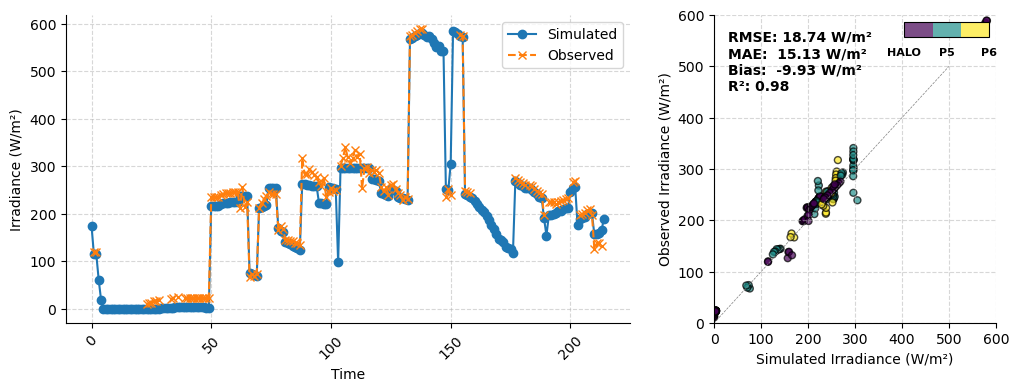

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

fig, (ax, ax_scatter) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})

# Convert airplane column to categorical to get codes and categories
airplane_cat = ds_to_sim['airplane'].to_series().astype('category')
airplane_codes = airplane_cat.cat.codes
airplane_types = airplane_cat.cat.categories
n_colors = len(airplane_types)

# Main plot
ax.plot(ds_sim_alt.eglo / 1e3, marker='o', linestyle='-', label='Simulated')
ax.plot(ds_to_sim.F_down_solar, marker='x', linestyle='--', label='Observed')
ax.set_xlabel('Time')
ax.set_ylabel('Irradiance (W/m²)')
ax.legend()
ax.tick_params(axis='x', rotation=45)


# Scatter plot
cmap = plt.get_cmap('viridis', n_colors)
scatter = ax_scatter.scatter(ds_sim_alt.eglo / 1e3, ds_to_sim.F_down_solar, c=airplane_codes, cmap=cmap, s=25, alpha=0.7, edgecolor='k')
ax_scatter.set_xlabel('Simulated Irradiance (W/m²)')
ax_scatter.set_ylabel('Observed Irradiance (W/m²)')
ax_scatter.set_xlim(0, 600)
ax_scatter.set_ylim(0, 600)
ax_scatter.plot(np.arange(0, 600, 100), np.arange(0, 600, 100), color='gray', linestyle='--', linewidth=0.5)

### calculate the correlation coefficient, rmse and bias


from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = ds_sim_alt.eglo.values / 1000
Y = ds_to_sim.F_down_solar.values
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask]
Y = Y[nan_mask]

rmse = np.sqrt(mean_squared_error(X, Y))
bias = np.mean(X - Y)
r2 = r2_score(X, Y)
mae = mean_absolute_error(X, Y)

stats_text = f'RMSE: {rmse:.2f} W/m²\nMAE:  {mae:.2f} W/m²\nBias:  {bias:.2f} W/m²\nR²: {r2:.2f}'
ax_scatter.text(0.05, 0.95, stats_text, transform=ax_scatter.transAxes, fontsize=10, verticalalignment='top', fontweight='bold',)


# Create an inset colorbar
cax = inset_axes(ax_scatter, width="30%", height="5%", loc='upper right')
norm = mcolors.BoundaryNorm(np.arange(n_colors + 1) - 0.5, n_colors)
cb = fig.colorbar(scatter, cax=cax, orientation='horizontal', ticks=np.arange(n_colors), norm=norm)
cb.set_ticklabels(airplane_types, fontweight='bold')
cb.ax.tick_params(labelsize=8)
# remove colorbar ticks and spines
cax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True, labeltop=False)
cax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)


for a in [ax, ax_scatter]:
    a.grid(True, linestyle='--', alpha=0.5)
    a.spines[['top', 'right']].set_visible(False)   


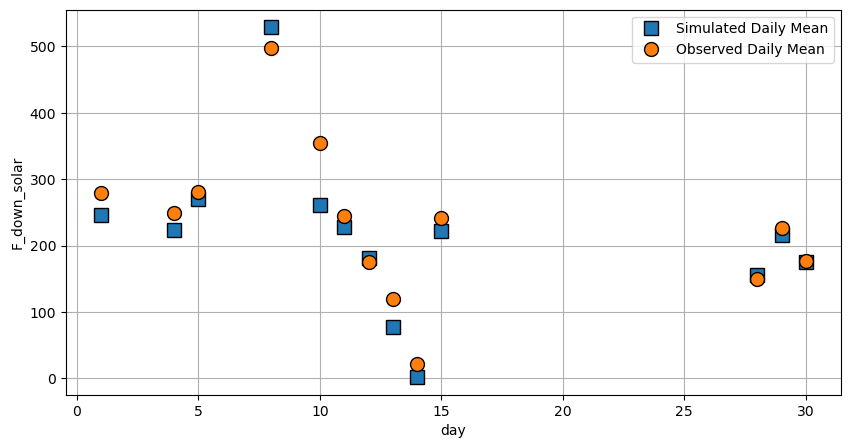

In [7]:
plt.figure(figsize=(10, 5))
(ds_sim_alt.groupby('time.day').mean()['eglo'] / 1000).plot(marker='s', ls='', ms=10, markeredgecolor='k', label='Simulated Daily Mean')
ds_to_sim['F_down_solar'].groupby('time.day').mean().plot(marker='o', ls='', ms=10, markeredgecolor='k', label='Observed Daily Mean')   
plt.legend()
plt.grid()


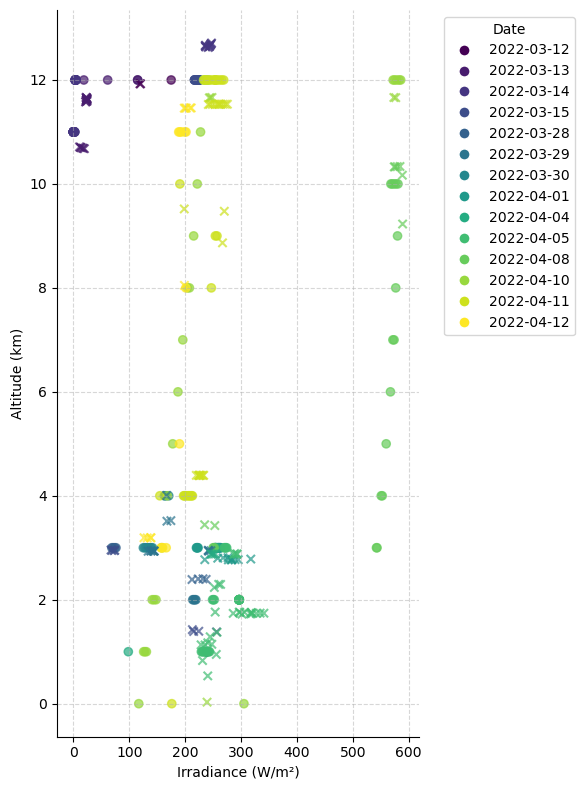

In [8]:
alt = ds_sim_alt.eglo.altitude.values

fig, ax = plt.subplots(1, figsize=(6,8))

ds_to_sim['z'] = ds['Alt'] / 1e3# Convert altitude to km for plotting

# Create categorical data for coloring by day
day_cat = ds_to_sim.time.to_series().dt.date.astype('category')
day_codes = day_cat.cat.codes
day_types = day_cat.cat.categories
n_colors = len(day_types)
cmap = plt.get_cmap('viridis', n_colors)


# Scatter plot for simulated data
scatter_sim = ax.scatter(ds_sim_alt.eglo.values / 1e3, alt, c=day_codes, cmap=cmap, marker='o', label='Simulated', alpha=0.7)
# Scatter plot for observed data
scatter_obs = ax.scatter(ds_to_sim.F_down_solar.values, ds_to_sim.z.values, c=day_codes, cmap=cmap, marker='x', label='Observed', alpha=0.7)

# Create a legend for the days
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=8) for i in range(n_colors)]
labels = [d.strftime('%Y-%m-%d') for d in day_types]
ax.legend(handles, labels, title="Date", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

ax.set_ylabel('Altitude (km)')
ax.set_xlabel('Irradiance (W/m²)')
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

## Comparing pyRadtran Simulations with Aircraft Observations and published Results

Text(0.05, 0.95, 'RMSE: 18.74 W/m²\nMAE:  15.13 W/m²\nBias:  -9.93 W/m²\nR²: 0.98')

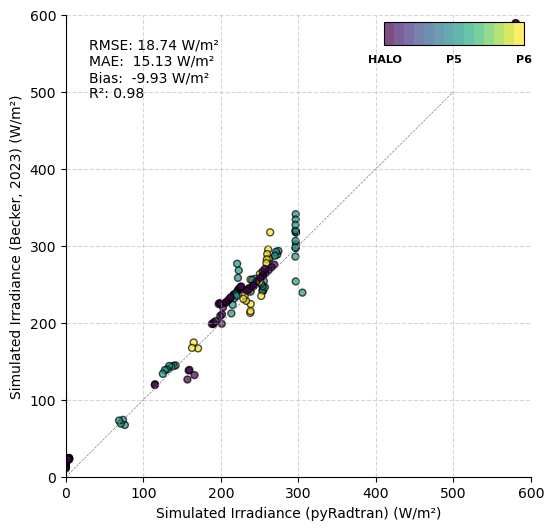

In [9]:
X = ds_sim_alt['eglo']
Y = ds_to_sim['F_down_solar']

fig, ax_scatter = plt.subplots(1, 1, figsize=(6, 6))

# Scatter plot
cmap = plt.get_cmap('viridis', n_colors)
scatter = ax_scatter.scatter(X / 1e3, Y, c=airplane_codes, cmap=cmap, s=25, alpha=0.7, edgecolor='k')
ax_scatter.set_xlabel('Simulated Irradiance (pyRadtran) (W/m²)')
ax_scatter.set_ylabel('Simulated Irradiance (Becker, 2023) (W/m²)')

n_colors = len(airplane_types)

# Set limits and add diagonal line
ax_scatter.set_xlim(0, 600)
ax_scatter.set_ylim(0, 600)
ax_scatter.plot(np.arange(0, 600, 100), np.arange(0, 600, 100), color='gray', linestyle='--', linewidth=0.5)
# Create an inset colorbar
cax = inset_axes(ax_scatter, width="30%", height="5%", loc='upper right')
norm = mcolors.BoundaryNorm(np.arange(n_colors + 1) - 0.5, n_colors)
cb = fig.colorbar(scatter, cax=cax, orientation='horizontal', ticks=np.arange(n_colors), norm=norm)
cb.set_ticklabels(airplane_types, fontweight='bold')
cb.ax.tick_params(labelsize=8)
# remove colorbar ticks and spines
cax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True, labeltop=False)
cax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)   
for a in [ax_scatter]:
    a.grid(True, linestyle='--', alpha=0.5)
    a.spines[['top', 'right']].set_visible(False)

# Calculate the correlation coefficient, RMSE, and bias
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask].values / 1000  # Convert to W/m
Y = Y[nan_mask].values

rmse = np.sqrt(mean_squared_error(X, Y))
bias = np.mean(X - Y)
r2 = r2_score(X, Y)
mae = mean_absolute_error(X, Y)

stats_text = f'RMSE: {rmse:.2f} W/m²\nMAE:  {mae:.2f} W/m²\nBias:  {bias:.2f} W/m²\nR²: {r2:.2f}'
ax_scatter.text(0.05, 0.95, stats_text, transform=ax_scatter.transAxes, fontsize=10, verticalalignment='top')

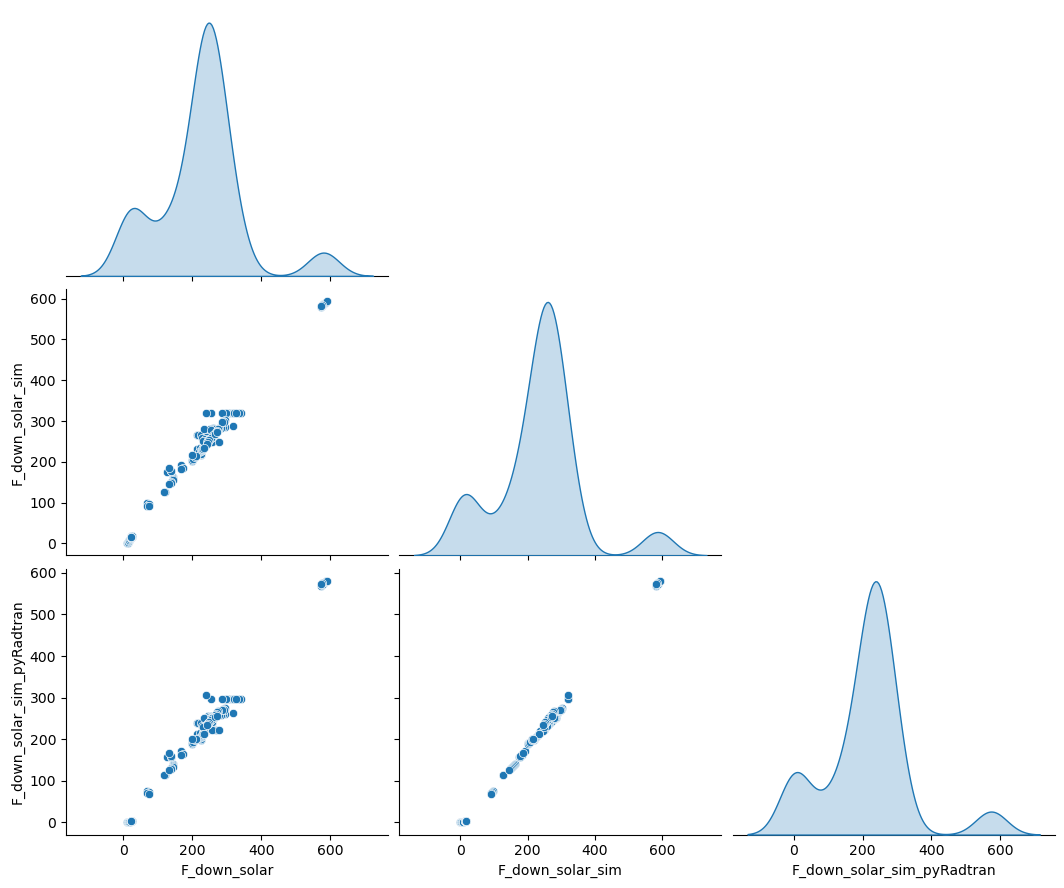

In [10]:
df_to_compare = ds[['F_down_solar', 'F_down_solar_sim']]
df_to_compare['F_down_solar_sim_pyRadtran'] = ('time', ds_sim_alt.eglo.values / 1000)  # Convert to W/m²

df_to_compare = df_to_compare.dropna('time', how='any').to_dataframe()
df_to_compare

### make this cool pandas scatter comparison plot where you can compare multiple columns 
import seaborn as sns
import matplotlib.pyplot as plt
#sns.set(style="whitegrid")
g = sns.pairplot(df_to_compare, kind='scatter', diag_kind='kde', markers=["o", "x"], height=3, aspect=1.2, corner=True)
